## Topic: Sequential Workflows in LangGraph

### Agenda:
- 1. Introduction of Sequential Workflow

- 2. Sequential vs Other Workflow Patterns

- 3.  Example 1: Simple Sequential Graph

- 4.  Example 2: Multi-Step Text Pipeline

- 5.  Example 3: Sequential RAG Pipeline

- 6.  Example 4: Sequential Data Processing

- 7. State Flow in Sequential Graphs

- 8. When to Use Sequential Workflows

- 9. Key Takeaways

### 1. Introduction of Sequential Workflow
- Definition:
    - A Sequential Workflow is the simplest graph pattern where nodes execute one after another in a fixed, linear order — like an assembly line.

- Main idea: 
    - A sequential workflow is a straight line of nodes. Data enters at the start, passes through each node in order, and exits at the end.

In [ ]:
""" 
Real-World Analogy: A Car Wash

  ┌───────┐     ┌───────┐    ┌───────┐    ┌───────┐    ┌──────┐
  │ SOAP  │───▶│ SCRUB │───▶│ RINSE │───▶│  DRY  │───▶│ DONE│
  └───────┘     └───────┘    └───────┘    └───────┘    └──────┘

  You cannot dry the car before rinsing it.
  You cannot rinse before soaping.
  The order is FIXED.

"""

In [ ]:
""" 
┌─────────────────────────────────────────────────────────────┐
│           WHY SEQUENTIAL FIRST?                             │
│                                                             │
│  1. SIMPLEST PATTERN                                        │
│     One edge between each pair of nodes. No routing logic.  │
│                                                             │
│  2. EASIEST TO DEBUG                                        │
│     If something breaks, you know exactly which step failed.│
│                                                             │
│  3. FOUNDATION FOR OTHER PATTERNS                           │
│     Parallel = multiple sequences running at once           │
│     Conditional = sequences with branches                   │
│     Iterative = sequences with loops                        │
│                                                             │
│  4. MOST COMMON IN PRODUCTION                               │
│     Many real workflows ARE sequential:                     │
│     Load → Clean → Transform → Store                        │
│     Retrieve → Grade → Generate → Format                    │
│                                                             │
│  5. MIRRORS LANGCHAIN CHAINS                                │
│     If you used LCEL chains (a | b | c), sequential         │
│     graphs are the LangGraph equivalent.                    │
└─────────────────────────────────────────────────────────────┘

"""

4


### 2. Sequential vs Other Workflow Patterns

In [ ]:
""" 
┌─────────────────────────────────────────────────────────────┐
│           THE FOUR WORKFLOW PATTERNS                        │
│                                                             │
│  1. SEQUENTIAL (Linear)          ← YOU ARE HERE             │
│     A → B → C → D → END                                     │
│     Fixed order. No branches. No loops.                     │
│                                                             │
│  2. PARALLEL (Fan-out / Fan-in)                             │
│          ┌→ B →┐                                            │
│     A →  ├→ C →├→ E → END                                   │
│          └→ D →┘                                            │
│     Multiple steps run at the same time.                    │
│                                                             │
│  3. CONDITIONAL (Branching)                                 │
│          ┌→ B (if X)                                        │
│     A →  ├→ C (if Y)  → END                                 │
│          └→ D (else)                                        │
│     Dynamic routing based on state.                         │
│                                                             │
│  4. ITERATIVE (Looping)                                     │
│     A → B → C → (check) → B → C → (check) → END             │
│     Repeats until a condition is met.                       │
└─────────────────────────────────────────────────────────────┘

"""


""" 
┌──────────────────────────────────────────────────────────────────┐
│          SEQUENTIAL vs OTHER PATTERNS                            │
│                                                                  │
│  FEATURE          SEQUENTIAL  PARALLEL  CONDITIONAL  ITERATIVE   │
│  ──────────────────────────────────────────────────────────────  │
│  Order            Fixed       Parallel  Dynamic      Repeating   │
│  Branches         No          No        Yes          No          │
│  Loops            No          No        No           Yes         │
│  Complexity       Low         Medium    Medium       High        │
│  Debugging        Easy        Medium    Hard         Hard        │
│  Use Case         Pipelines   Speed     Decisions    Refinement  │
│  Example          ETL pipe    Research  RAG grading  Self-fix    │
│  LangGraph Edges  add_edge    Multiple  Conditional  Back-edge   │
│                   (normal)    edges     edges        to earlier  │
│                                                        node      │
└──────────────────────────────────────────────────────────────────┘


"""

### 3.  Example 1: Simple Sequential Graph

- 1. Install the basic packages
    - pip install -U langgraph langchain langchain-core

- 2. Install Groq integration
    - pip install langchain-groq python-dotenv


- 3. Make sure Ollama is running
    - See the downloaded model list:
        - ollama list

    - downloaded it:
        - ollama pull llama3.2:latest

    - Install the required packages:
        - pip install -U langgraph langchain langchain-core langchain-ollama



- Key Note:
    - LangGraph → LangChain → Groq API → Cloud LLM

    - LangGraph → LangChain → Ollama → Local llama3.2

#### Example 1: Simple Sequential Graph __First Workflow
- This is not LLM integration LLM.

- Problem statement: Create a BMI Calculator that Calculate the BMI based on provide input (height(m), weight(kg))

#### Import Necessary Libraries
from langgraph.graph import StateGraph
- StateGraph:
    - To Create a Graph we use the StateGraph

- Syntax of StateGraph:
    - obj_stategraph = StateGraph(state_schema_class)
    


In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

#### 1. Define state

In [6]:
# 1. Define state

class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float 

#### 2. Define the Node

In [9]:
# first calculate_bmi note
def calculate_bmi(state: BMIState) -> BMIState:
    
    # extract schema from BMIState state
    weight = state["weight_kg"]
    height = state["height_m"]

    # calculate the bmi
    bmi = weight/(height**2)

    # Partial update the state
    state["bmi"] = bmi

    # return the state
    return state


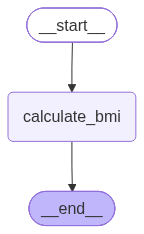

In [11]:
# 2. Define Graph using StateGraph class [ START --> calculate_bmi ---> END]

graph = StateGraph(BMIState)

# 3. Add notes --> to graph
graph.add_node("calculate_bmi", calculate_bmi)

# 4. Add edges --> to graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

# 5. Compile the graph
graph.compile()


In [12]:
# 5. Compile the graph
workflow = graph.compile()

# 6. Execute the graph

output_state = workflow.invoke({
    "weight_kg": 65.05,
    "height_m": 1.651
})

print(f"Output State: \n{output_state}")

Output State: 
{'weight_kg': 65.05, 'height_m': 1.651, 'bmi': 23.864544770509657}


- Key Note:
    - Graph input is a State.
    - Graph output is a State also.

In [13]:
# another way
initial_state = {
    "weight_kg": 65.05,
    "height_m": 1.651
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 65.05, 'height_m': 1.651, 'bmi': 23.864544770509657}


### To visual The Graph

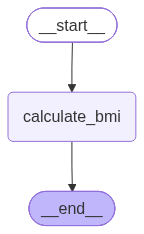

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Add some complexity into the Graph

- workflow:
    - START --> cal_bmi ---> label_bmi ---> END

    - where, 
        - cal_bmi : Calculate the BMI Value
        - label_bmi: Label the BMI Value (like, Underweight, HealthyWeight, Overweight, Obesity)

In [15]:
# import necessary libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [ ]:
# 1. Define the State (schema)

class BMI_State(TypedDict):
    weight_kg : float
    height_m : float
    bmi_value: float
    bmi_category: str 


In [17]:
### 3. Initialize the First Node
def cal_bmi(state: BMI_State) -> BMI_State:
    # Extract the value from state
    weight = state['weight_kg']
    height = state['height_m']

    # calculate the bmi
    bmi_value = weight/(height**2)

    # Partial update the state
    state['bmi_value'] = bmi_value

    # return the bmi value
    return state

In [18]:
### 4. Initialize the Second state

def cal_category(state: BMI_State) -> BMI_State:
    # Extract the value
    bmi_value = state['bmi_value']

    # calculate the category
    if bmi_value > 30.0:
        # partial update
        state['bmi_category'] = "Obesity"

    # calculate the category
    elif bmi_value > 25.0:
        # partial update
        state['bmi_category'] = "Overweight"

    # calculate the category
    elif bmi_value > 18.5:
        # partial update
        state['bmi_category'] = "HealthyWeight"

    else:
        # partial update
        state['bmi_category'] = "Underweight"


    return state


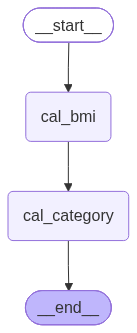

In [20]:
# 2. Define the Graph
graph = StateGraph(BMI_State)

# add node to the Graph
graph.add_node("cal_bmi",cal_bmi)
graph.add_node("cal_category",cal_category)


# add edges to the Graph
graph.add_edge(START, "cal_bmi")
graph.add_edge("cal_bmi", "cal_category")
graph.add_edge("cal_category", END)


# compile the Graph
graph.compile()

In [22]:
# compile the Graph
workflow = graph.compile()

# execute the Graph
initial_state = {
    "weight_kg": 61.05,
     "height_m": 1.676
}

final_state = workflow.invoke(initial_state)


print(final_state)

{'weight_kg': 61.05, 'height_m': 1.676, 'bmi_value': 21.73389875883596, 'bmi_category': 'HealthyWeight'}
